# Prediksi Harga Multi-Aset Menggunakan Algoritma ARIMA

---

| Keterangan | Detail |
|---|---|
| **Mata Kuliah** | AI in Business |
| **Topik** | Time Series Forecasting – Multi-Aset |
| **Algoritma** | ARIMA (AutoRegressive Integrated Moving Average) |
| **Dataset** | 6 Aset Keuangan dari Yahoo Finance (2020–2026) |
| **Aset** | Emas · Bitcoin · Minyak Mentah · Apple · Microsoft · Ethereum |
| **Evaluasi** | MSE · MAE · RMSE · Dstat (Directional Statistic) |
| **Prediksi** | 30 hari ke depan per aset |

---


## 1. Pendahuluan

### Apa itu Forecasting (Peramalan)?
**Forecasting** adalah proses memperkirakan nilai masa depan berdasarkan data historis dan pola statistik.
Dalam dunia keuangan, forecasting sangat penting untuk:
- Pengambilan keputusan investasi yang lebih rasional
- Manajemen risiko portofolio
- Perencanaan strategi bisnis jangka panjang

### Apa itu Time Series Forecasting?
**Time Series Forecasting** memanfaatkan data yang dikumpulkan secara berurutan dalam interval waktu tertentu
(harian, mingguan, bulanan). Harga saham, kripto, dan komoditas adalah contoh klasik data time series.

### Apa itu ARIMA?
**ARIMA** (AutoRegressive Integrated Moving Average) adalah model statistik paling populer untuk peramalan
time series. Terdiri dari tiga komponen utama:

| Komponen | Notasi | Penjelasan |
|---|---|---|
| AutoRegressive | AR(p) | Menggunakan nilai masa lalu sebagai prediktor |
| Integrated | I(d) | Proses differencing untuk membuat data stasioner |
| Moving Average | MA(q) | Menggunakan kesalahan prediksi masa lalu |

### Mengapa 6 Aset dari Kelas Berbeda?
Menguji ARIMA pada aset dari kelas yang berbeda memungkinkan kita memahami sejauh mana model
statistik linear ini bekerja pada berbagai karakteristik volatilitas dan tren pasar.

| No | Aset | Ticker | Kelas |
|---|---|---|---|
| 1 | Emas (Gold Futures) | GC=F | Komoditas |
| 2 | Bitcoin | BTC-USD | Kripto |
| 3 | Minyak Mentah (Crude Oil) | CL=F | Komoditas |
| 4 | Apple Inc. | AAPL | Saham |
| 5 | Microsoft Corp. | MSFT | Saham |
| 6 | Ethereum | ETH-USD | Kripto |


## 2. Import Library & Konfigurasi

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.image as mpimg
import json
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path
from IPython.display import Image, display
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller
from statsmodels.tools.sm_exceptions import ConvergenceWarning
from sklearn.metrics import mean_squared_error, mean_absolute_error

try:
    plt.style.use('seaborn-v0_8-whitegrid')
except Exception:
    plt.style.use('ggplot')

DATA_RAW   = Path('reports/hasil/result_multi_asset/data/raw')
DATA_PROC  = Path('reports/hasil/result_multi_asset/data/processed')
MODELS_DIR = Path('reports/hasil/result_multi_asset/models')
OUTPUT_DIR = Path('reports/hasil/result_multi_asset')
CHARTS_DIR = OUTPUT_DIR / 'charts_individual'

ASSETS = {
    'Emas':      {'ticker': 'GC=F',    'category': 'Komoditas', 'color': '#C9A800', 'freq': 'B'},
    'Bitcoin':   {'ticker': 'BTC-USD', 'category': 'Kripto',    'color': '#F7931A', 'freq': 'D'},
    'Minyak':    {'ticker': 'CL=F',    'category': 'Komoditas', 'color': '#2E8B57', 'freq': 'B'},
    'Apple':     {'ticker': 'AAPL',    'category': 'Saham',     'color': '#555555', 'freq': 'B'},
    'Microsoft': {'ticker': 'MSFT',    'category': 'Saham',     'color': '#00A4EF', 'freq': 'B'},
    'Ethereum':  {'ticker': 'ETH-USD', 'category': 'Kripto',    'color': '#627EEA', 'freq': 'D'},
}

TEST_SIZE     = 10
FORECAST_DAYS = 30

print('Setup selesai.')
import statsmodels, yfinance
print(f'  pandas={pd.__version__}  numpy={np.__version__}')
print(f'  statsmodels={statsmodels.__version__}  yfinance={yfinance.__version__}')


Setup selesai.
  pandas=3.0.3  numpy=2.4.6
  statsmodels=0.14.6  yfinance=1.3.0


## 3. Overview Dataset

Dataset diunduh dari **Yahoo Finance** menggunakan `yfinance` dengan periode **2020-01-01 hingga hari ini**.
Pipeline 01 menyimpan setiap aset ke CSV di `data/raw/`.

| Kolom | Keterangan |
|---|---|
| **Open** | Harga pembukaan sesi perdagangan |
| **High** | Harga tertinggi dalam satu hari |
| **Low** | Harga terendah dalam satu hari |
| **Close** | Harga penutupan *(target prediksi)* |
| **Volume** | Jumlah unit yang diperdagangkan |


In [2]:
all_data = {}
for name in ASSETS:
    df = pd.read_csv(DATA_RAW / f'{name}.csv', index_col=0, parse_dates=True)
    df.index = pd.to_datetime(df.index)
    all_data[name] = df

print('RINGKASAN DATASET')
print('=' * 72)
print(f'  {"Aset":<12} {"Ticker":<10} {"Kategori":<12} {"Baris":>6} {"Mulai":<12} {"Akhir":<12}')
print('  ' + '-' * 68)
for name, df in all_data.items():
    info = ASSETS[name]
    print(f'  {name:<12} {info["ticker"]:<10} {info["category"]:<12} '
          f'{len(df):>6} {str(df.index[0].date()):<12} {str(df.index[-1].date()):<12}')


RINGKASAN DATASET
  Aset         Ticker     Kategori      Baris Mulai        Akhir       
  --------------------------------------------------------------------
  Emas         GC=F       Komoditas      1607 2020-01-02   2026-05-21  
  Bitcoin      BTC-USD    Kripto         2332 2020-01-01   2026-05-20  
  Minyak       CL=F       Komoditas      1607 2020-01-02   2026-05-21  
  Apple        AAPL       Saham          1605 2020-01-02   2026-05-21  
  Microsoft    MSFT       Saham          1605 2020-01-02   2026-05-21  
  Ethereum     ETH-USD    Kripto         2332 2020-01-01   2026-05-20  


In [3]:
stats = pd.DataFrame({name: df['Close'].describe() for name, df in all_data.items()}).round(2)
print('RINGKASAN STATISTIK HARGA CLOSE (USD)')
print('=' * 72)
display(stats)


RINGKASAN STATISTIK HARGA CLOSE (USD)


,Emas,Bitcoin,Minyak,Apple,Microsoft,Ethereum
count,1607.00,2332.00,1607.00,1605.00,1605.00,2332.00
mean,2349.24,48944.02,70.69,170.76,320.69,2174.29
std,881.40,31314.03,18.89,53.95,100.71,1146.73
min,1477.30,4970.79,-37.63,54.16,128.36,110.61
25%,1799.95,23138.95,61.57,133.50,237.60,1553.52
50%,1933.00,42279.10,71.78,167.62,306.59,2120.29
75%,2626.55,68297.19,80.92,211.48,408.33,3037.84
max,5318.40,124752.53,123.70,304.99,538.66,4831.35


In [4]:
print('5 Baris PERTAMA – Emas (GC=F)')
display(all_data['Emas'].head())
print()
print('5 Baris TERAKHIR – Emas (GC=F)')
display(all_data['Emas'].tail())


5 Baris PERTAMA – Emas (GC=F)


,Close,High,Low,Open,Volume
Date,,,,,
2020-01-02,1524.500000,1528.699951,1518.000000,1518.099976,214
2020-01-03,1549.199951,1552.699951,1530.099976,1530.099976,107
2020-01-06,1566.199951,1580.000000,1560.400024,1580.000000,416
2020-01-07,1571.800049,1576.300049,1558.300049,1558.300049,47
2020-01-08,1557.400024,1604.199951,1552.300049,1579.699951,236



5 Baris TERAKHIR – Emas (GC=F)


,Close,High,Low,Open,Volume
Date,,,,,
2026-05-15,4555.799805,4615.200195,4524.299805,4615.200195,607
2026-05-18,4552.500000,4570.299805,4538.700195,4563.000000,38
2026-05-19,4506.299805,4552.600098,4506.200195,4551.700195,875
2026-05-20,4531.299805,4531.299805,4465.100098,4502.600098,981
2026-05-21,4539.799805,4539.799805,4503.799805,4507.200195,981


In [5]:
print('PEMERIKSAAN MISSING VALUES')
print('=' * 65)
print(f'  {"Aset":<12} {"Open":>6} {"High":>6} {"Low":>6} {"Close":>7} {"Volume":>8}')
print('  ' + '-' * 55)
for name, df in all_data.items():
    mv = df.isnull().sum()
    print(f'  {name:<12} {mv.get("Open",0):>6} {mv.get("High",0):>6} '
          f'{mv.get("Low",0):>6} {mv.get("Close",0):>7} {mv.get("Volume",0):>8}')


PEMERIKSAAN MISSING VALUES
  Aset           Open   High    Low   Close   Volume
  -------------------------------------------------------
  Emas              0      0      0       0        0
  Bitcoin           0      0      0       0        0
  Minyak            0      0      0       0        0
  Apple             0      0      0       0        0
  Microsoft         0      0      0       0        0
  Ethereum          0      0      0       0        0


## 4. Exploratory Data Analysis (EDA)

1. **Harga historis** – tren jangka panjang tiap aset
2. **Moving Average** – tren halus dan sinyal pasar
3. **Distribusi return harian** – volatilitas relatif
4. **Volume perdagangan** – aktivitas pasar


### 4.1 Harga Historis & Moving Average 30 Hari

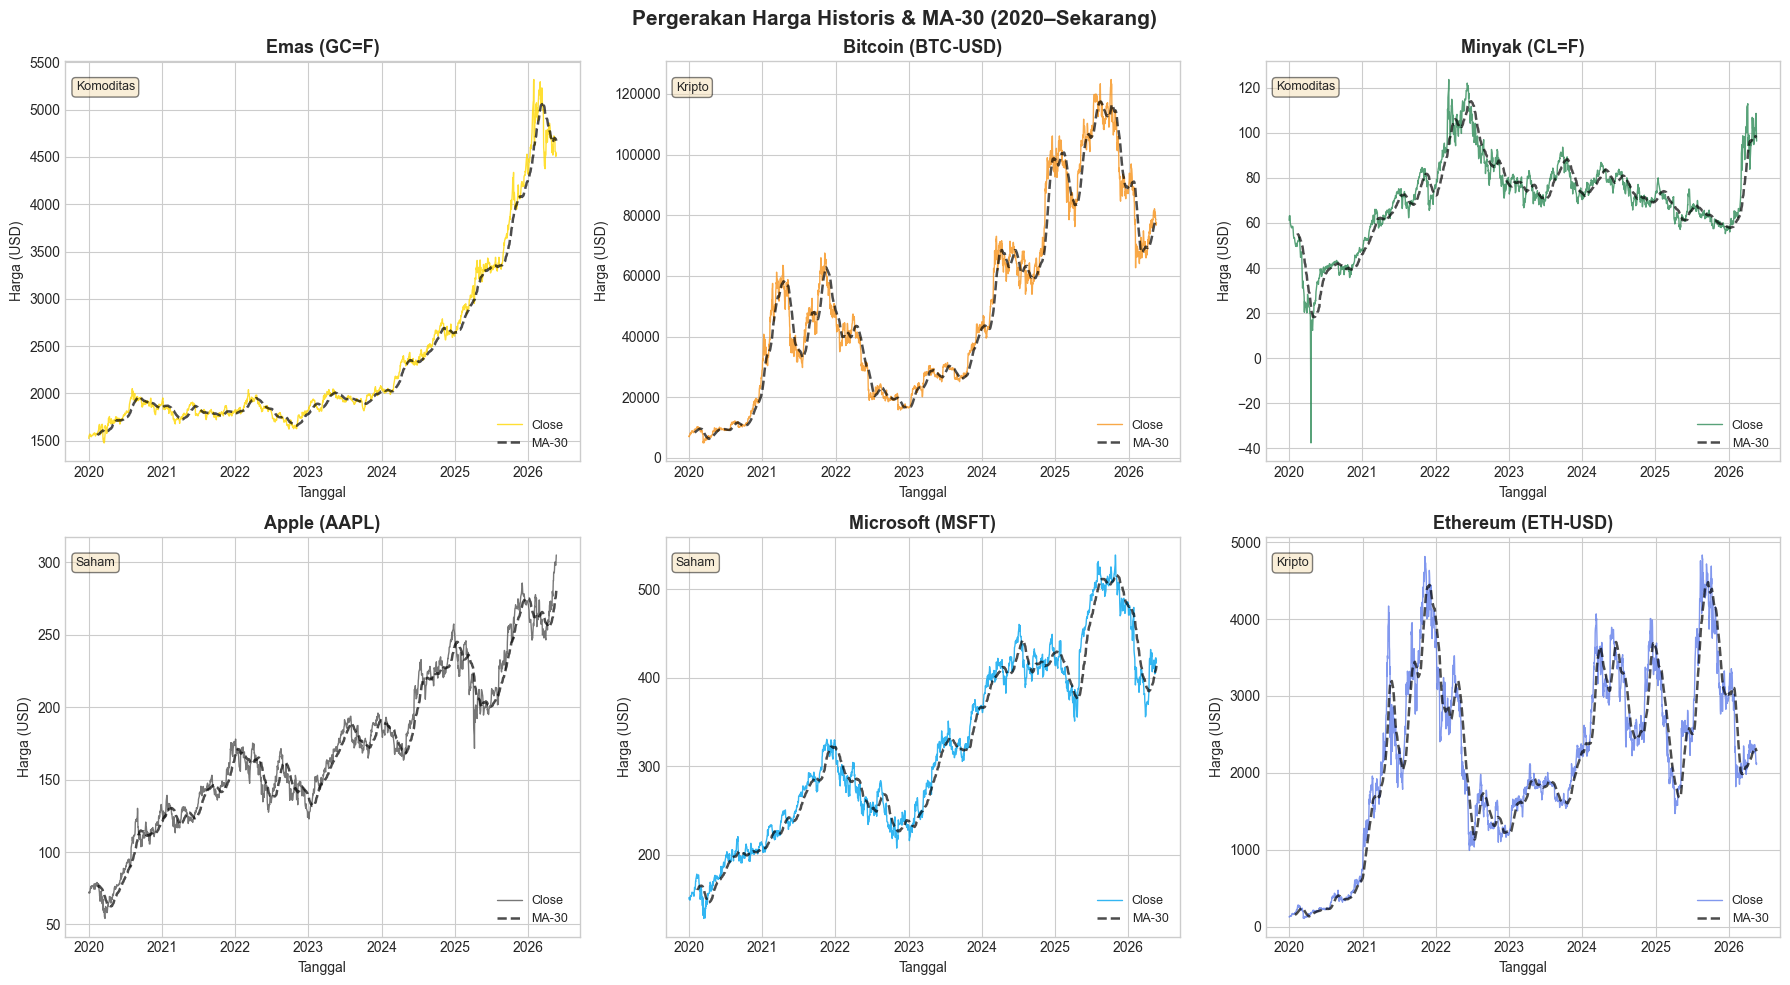

In [6]:
display(Image(filename=str(OUTPUT_DIR / 'eda_01_historical_prices.png'), width=950))


**Insight:** Setiap aset memiliki karakter berbeda.
- **Emas & Minyak**: tren bertahap, volatilitas sedang
- **Bitcoin & Ethereum**: pertumbuhan eksplosif + drawdown tajam
- **Apple & Microsoft**: pertumbuhan stabil mengikuti kinerja bisnis


### 4.2 Moving Average 7 Hari & 30 Hari

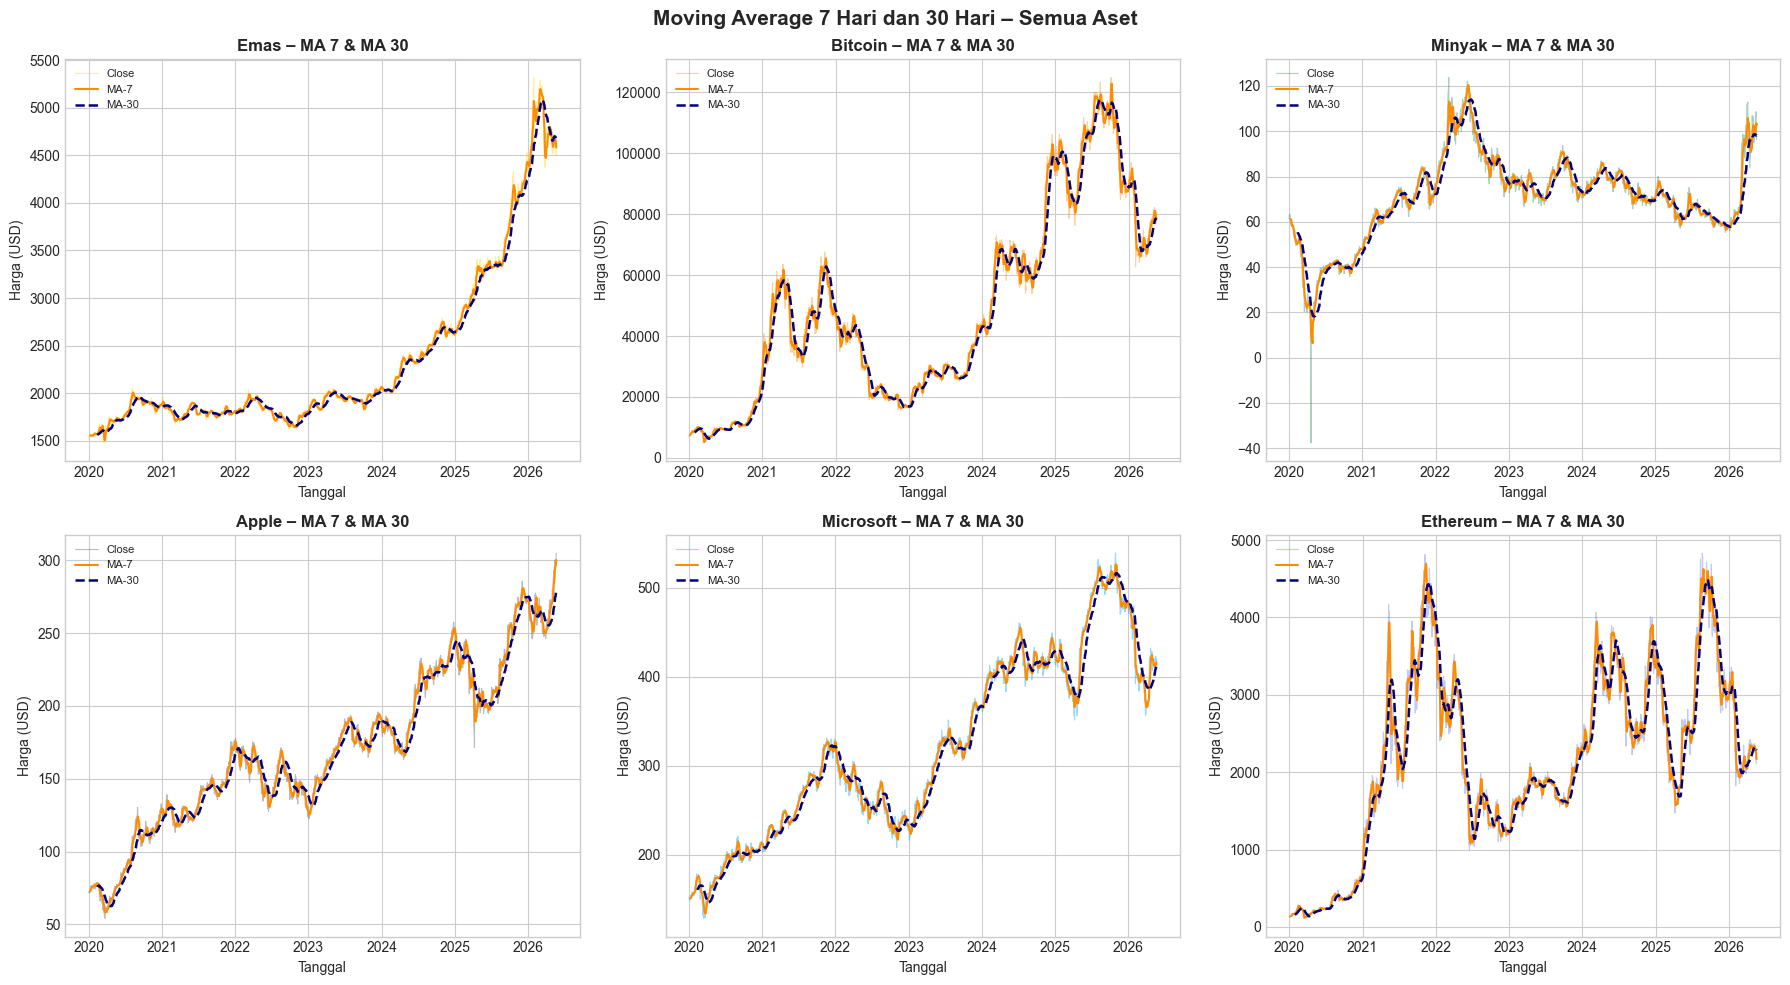

In [7]:
display(Image(filename=str(OUTPUT_DIR / 'eda_02_moving_averages.png'), width=950))


**Insight:** *Golden cross* (MA-7 melewati MA-30 dari bawah) = sinyal beli;
*Death cross* (sebaliknya) = sinyal jual.


### 4.3 Distribusi Return Harian

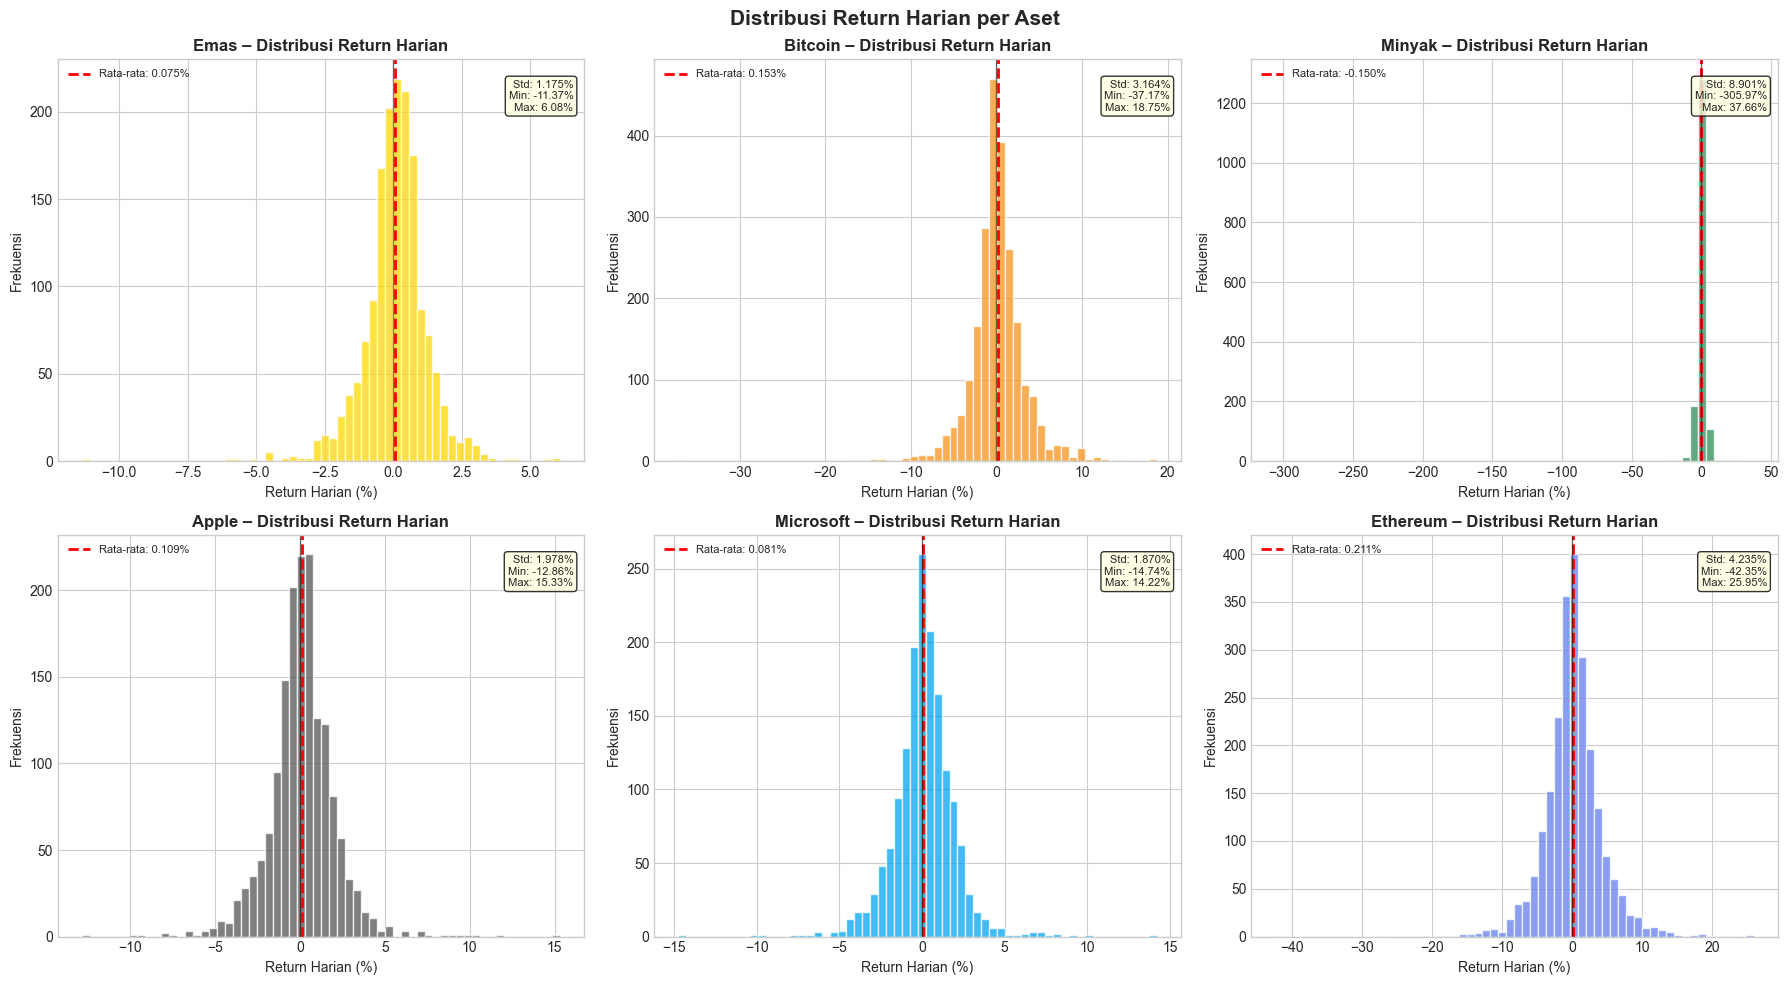

In [8]:
display(Image(filename=str(OUTPUT_DIR / 'eda_03_daily_returns.png'), width=950))


In [9]:
print('VOLATILITAS RETURN HARIAN (%)')
print('=' * 65)
print(f'  {"Aset":<12} {"Std Dev":>10} {"Min":>10} {"Max":>10} {"Skewness":>10}')
print('  ' + '-' * 55)
for name, df in all_data.items():
    r = df['Close'].pct_change().dropna() * 100
    print(f'  {name:<12} {r.std():>10.3f} {r.min():>10.2f} {r.max():>10.2f} {r.skew():>10.3f}')


VOLATILITAS RETURN HARIAN (%)
  Aset            Std Dev        Min        Max   Skewness
  -------------------------------------------------------
  Emas              1.175     -11.37       6.08     -0.779
  Bitcoin           3.164     -37.17      18.75     -0.467
  Minyak            8.901    -305.97      37.66    -27.027
  Apple             1.978     -12.86      15.33      0.274
  Microsoft         1.870     -14.74      14.22      0.009
  Ethereum          4.235     -42.35      25.95     -0.183


### 4.4 Volume Perdagangan

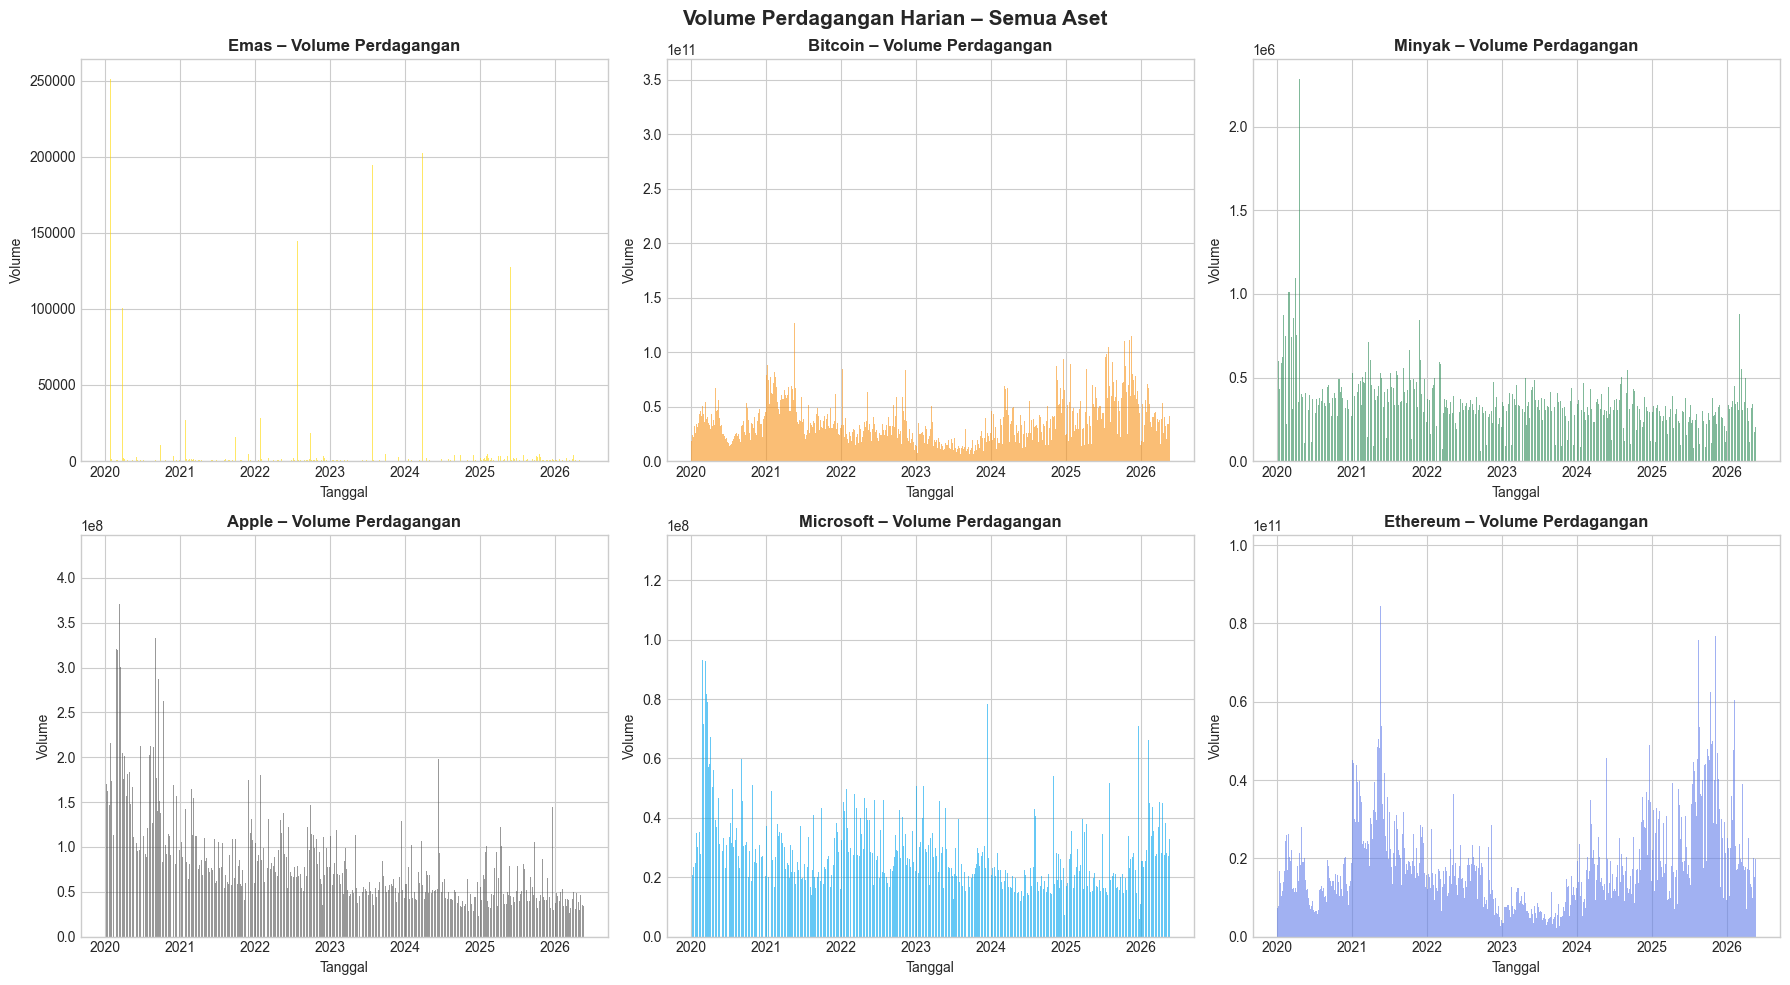

In [10]:
display(Image(filename=str(OUTPUT_DIR / 'eda_04_volume.png'), width=950))


## 5. Pra-pemrosesan Data (Preprocessing)

Langkah yang dilakukan:
1. Konversi index ke `datetime`
2. Sortir ascending berdasarkan tanggal
3. Isi gap kalender dengan *forward-fill* dan *backward-fill*
4. Gunakan kolom **Close** sebagai target prediksi

> **Mengapa forward-fill?** Pasar tutup di hari libur/akhir pekan.
> Forward-fill mengisi tanggal tersebut dengan harga terakhir yang tersedia
> tanpa memperkenalkan informasi palsu.


In [11]:
close_series = {}
for name, info in ASSETS.items():
    close = pd.read_csv(
        DATA_PROC / f'{name}_close_clean.csv',
        index_col=0, parse_dates=True
    ).squeeze('columns')
    close_series[name] = close

print('DATA SETELAH PREPROCESSING')
print('=' * 72)
print(f'  {"Aset":<12} {"Freq":<5} {"Total Baris":>12} {"Min Harga":>12} {"Max Harga":>12}')
print('  ' + '-' * 60)
for name, close in close_series.items():
    freq = ASSETS[name]['freq']
    print(f'  {name:<12} {freq:<5} {len(close):>12} {close.min():>12.2f} {close.max():>12.2f}')


DATA SETELAH PREPROCESSING
  Aset         Freq   Total Baris    Min Harga    Max Harga
  ------------------------------------------------------------
  Emas         B             1666      1477.30      5318.40
  Bitcoin      D             2332      4970.79    124752.53
  Minyak       B             1666       -37.63       123.70
  Apple        B             1666        54.16       304.99
  Microsoft    B             1666       128.36       538.66
  Ethereum     D             2332       110.61      4831.35


## 6. Uji Stasioneritas (ADF Test)

**Stasioneritas** adalah syarat utama model ARIMA: rata-rata, variansi, dan autokorelasi data
tidak boleh berubah seiring waktu.

**Augmented Dickey-Fuller (ADF) Test:**
- **H0**: Data tidak stasioner
- **H1**: Data stasioner
- p-value < 0.05 → stasioner

Jika tidak stasioner → lakukan **differencing** (d=1).


In [12]:
def uji_adf(series, label=''):
    result = adfuller(series.dropna(), autolag='AIC')
    p_val  = result[1]
    return {'label': label, 'stat': round(result[0], 4),
            'p_value': round(p_val, 6),
            'status': 'STASIONER [OK]' if p_val < 0.05 else 'TIDAK STASIONER [!!]'}

print('ADF TEST – DATA ASLI (LEVEL)')
print('=' * 68)
print(f'  {"Aset":<12} {"ADF Stat":>12} {"p-value":>12}  {"Status"}')
print('  ' + '-' * 60)
for name, close in close_series.items():
    r = uji_adf(close, name)
    print(f'  {name:<12} {r["stat"]:>12.4f} {r["p_value"]:>12.6f}  {r["status"]}')
print()
print('Semua aset TIDAK stasioner pada level harga -> differencing d=1.')


ADF TEST – DATA ASLI (LEVEL)
  Aset             ADF Stat      p-value  Status
  ------------------------------------------------------------
  Emas               1.4937     0.997501  TIDAK STASIONER [!!]
  Bitcoin           -1.3341     0.613445  TIDAK STASIONER [!!]
  Minyak            -1.9079     0.328356  TIDAK STASIONER [!!]
  Apple             -0.3515     0.917879  TIDAK STASIONER [!!]
  Microsoft         -1.4693     0.548630  TIDAK STASIONER [!!]
  Ethereum          -2.4491     0.128350  TIDAK STASIONER [!!]

Semua aset TIDAK stasioner pada level harga -> differencing d=1.


In [13]:
print('ADF TEST – SETELAH DIFFERENCING PERTAMA (d=1)')
print('=' * 68)
print(f'  {"Aset":<12} {"ADF Stat":>12} {"p-value":>12}  {"Status"}')
print('  ' + '-' * 60)
close_diff = {}
for name, close in close_series.items():
    diff = close.diff().dropna()
    close_diff[name] = diff
    r = uji_adf(diff, name)
    print(f'  {name:<12} {r["stat"]:>12.4f} {r["p_value"]:>12.6f}  {r["status"]}')
print()
print('Semua aset STASIONER setelah d=1 -> gunakan d=1 di ARIMA(p,1,q).')


ADF TEST – SETELAH DIFFERENCING PERTAMA (d=1)
  Aset             ADF Stat      p-value  Status
  ------------------------------------------------------------
  Emas              -7.8255     0.000000  STASIONER [OK]
  Bitcoin          -50.7030     0.000000  STASIONER [OK]
  Minyak            -9.3275     0.000000  STASIONER [OK]
  Apple            -14.3783     0.000000  STASIONER [OK]
  Microsoft        -13.3083     0.000000  STASIONER [OK]
  Ethereum         -17.3814     0.000000  STASIONER [OK]

Semua aset STASIONER setelah d=1 -> gunakan d=1 di ARIMA(p,1,q).


### 6.1 Rolling Mean & Standar Deviasi

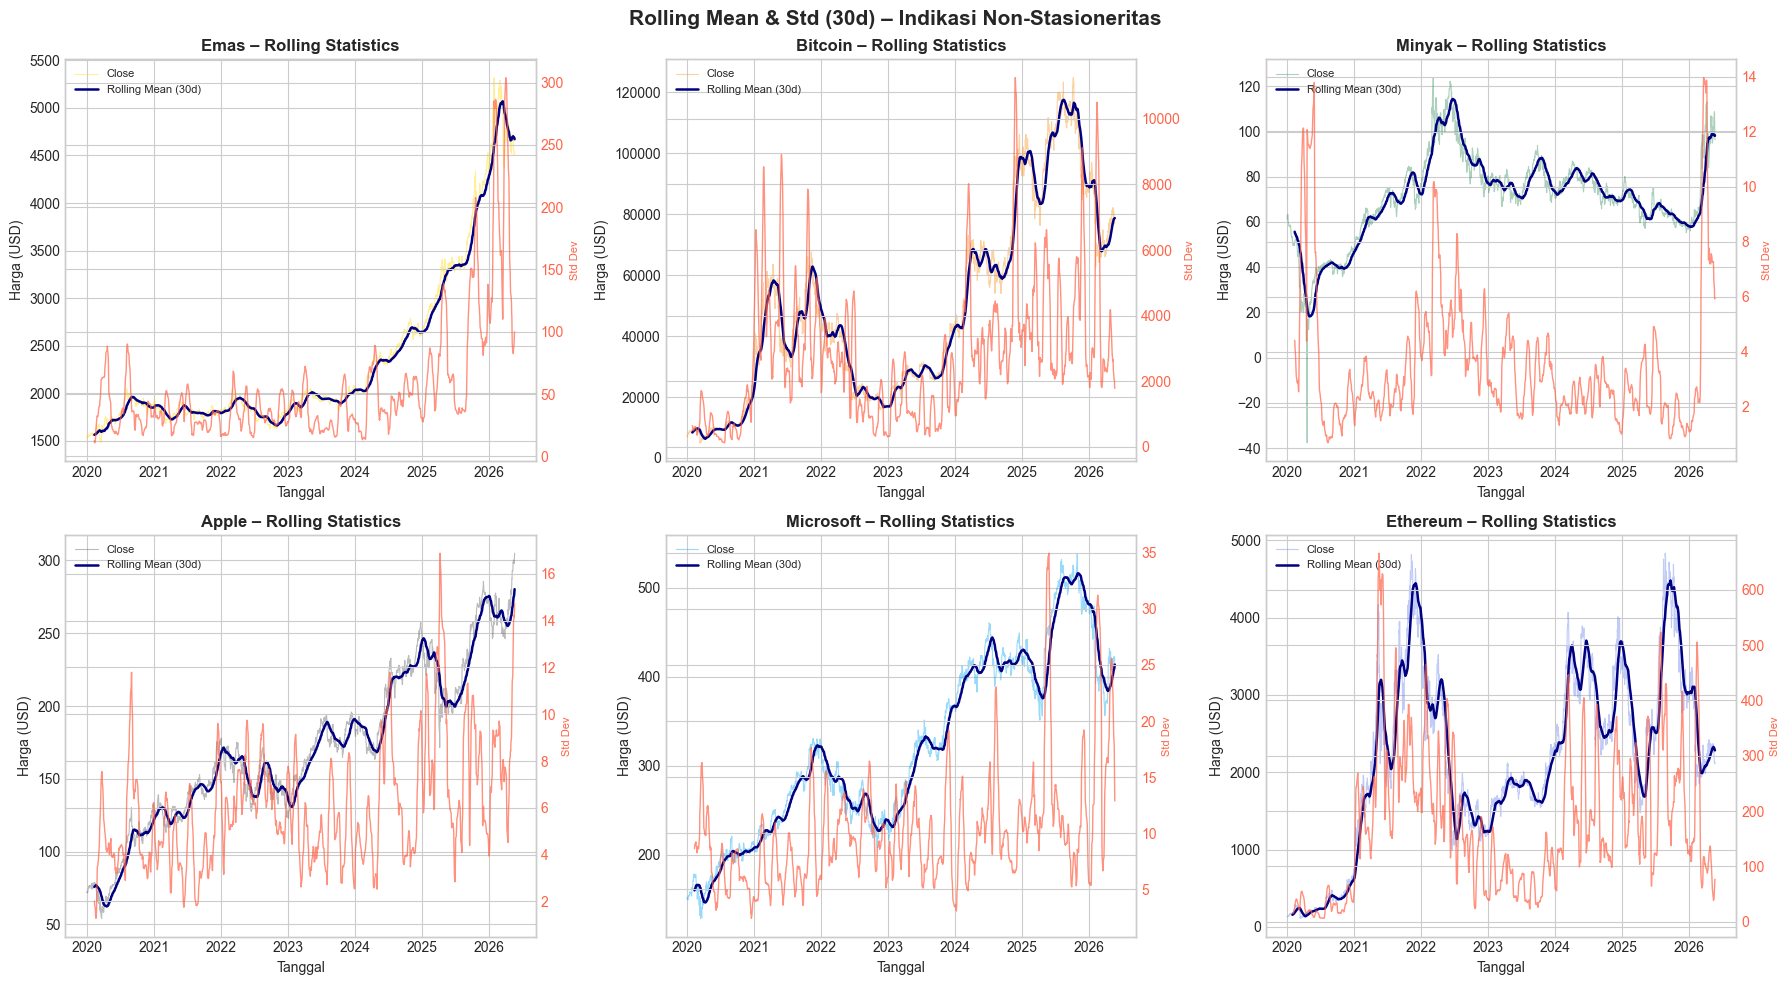

In [14]:
display(Image(filename=str(OUTPUT_DIR / 'eda_05_rolling_stats.png'), width=950))


### 6.2 ACF & PACF (Emas sebagai Representasi)

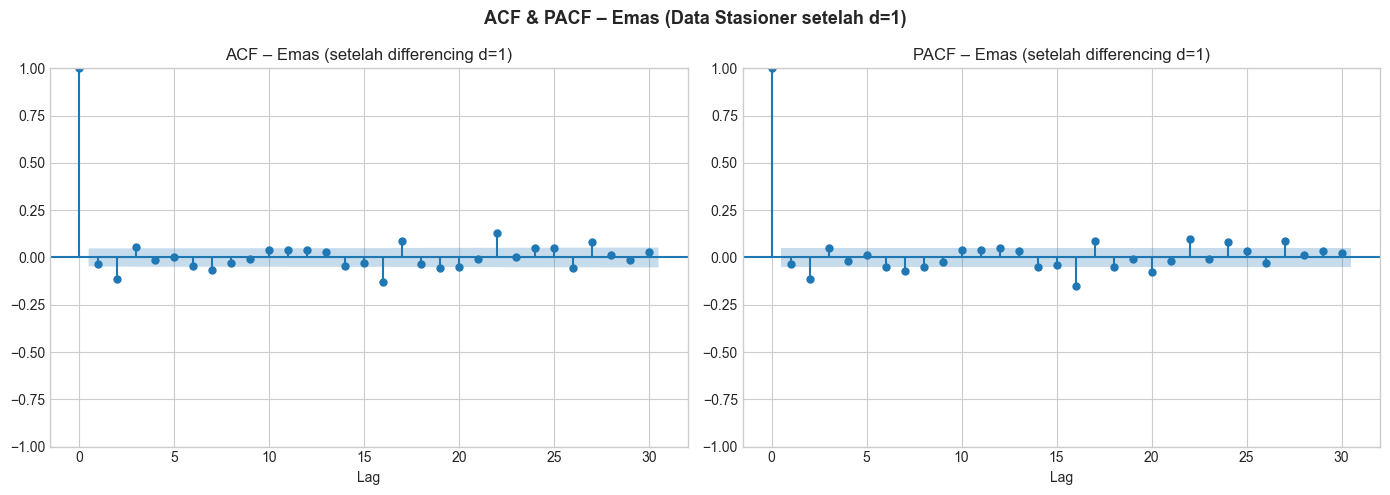

In [15]:
display(Image(filename=str(OUTPUT_DIR / 'eda_06_acf_pacf.png'), width=850))


**Cara membaca:**
- **PACF** → lag signifikan terakhir = perkiraan orde **p** (AR)
- **ACF** → lag signifikan terakhir = perkiraan orde **q** (MA)
- Grid search AIC di Pipeline 04 menentukan p dan q terbaik per aset.


## 7. Pembagian Data Latih dan Uji

Time series **tidak boleh dikocok acak** — pembagian harus mempertahankan urutan waktu:
- **Data latih**: semua observasi kecuali 10 terakhir
- **Data uji**: 10 observasi terakhir (evaluasi model)

Evaluasi menggunakan **walk-forward one-step-ahead** — setiap langkah model di-refit
dengan data aktual terbaru sebelum memprediksi langkah berikutnya.


In [16]:
print('PEMBAGIAN DATA LATIH-UJI (10 observasi terakhir sebagai data uji)')
print('=' * 72)
print(f'  {"Aset":<12} {"Total":>7} {"Latih":>7} {"Uji":>5}  {"Periode Uji"}')
print('  ' + '-' * 65)
for name, close in close_series.items():
    train   = close.iloc[:-TEST_SIZE]
    test    = close.iloc[-TEST_SIZE:]
    periode = f'{test.index[0].date()} s.d. {test.index[-1].date()}'
    print(f'  {name:<12} {len(close):>7} {len(train):>7} {len(test):>5}  {periode}')


PEMBAGIAN DATA LATIH-UJI (10 observasi terakhir sebagai data uji)
  Aset           Total   Latih   Uji  Periode Uji
  -----------------------------------------------------------------
  Emas            1666    1656    10  2026-05-08 s.d. 2026-05-21
  Bitcoin         2332    2322    10  2026-05-11 s.d. 2026-05-20
  Minyak          1666    1656    10  2026-05-08 s.d. 2026-05-21
  Apple           1666    1656    10  2026-05-08 s.d. 2026-05-21
  Microsoft       1666    1656    10  2026-05-08 s.d. 2026-05-21
  Ethereum        2332    2322    10  2026-05-11 s.d. 2026-05-20


## 8. Pemodelan ARIMA

Parameter ARIMA dipilih melalui **grid search AIC** (Pipeline 04):
- **p** dan **q**: diuji pada rentang 0–3
- **d = 1**: tetap (divalidasi ADF test)
- **trend**: `'n'` (tanpa drift) atau `'t'` (linear trend)

> **Catatan:** `trend='c'` **tidak valid** untuk `d=1` di statsmodels 0.14
> karena konstanta tersebut tereliminasi oleh differencing.
> Gunakan `trend='t'` (setara konstanta pada data differenced).


In [17]:
with open(MODELS_DIR / 'best_params.json') as f:
    best_params = json.load(f)

print('PARAMETER ARIMA TERBAIK (Grid Search AIC | d=1 | p,q in [0-3])')
print('=' * 70)
print(f'  {"Aset":<12} {"Order":<14} {"Trend":<8} {"AIC":>10} {"BIC":>10}')
print('  ' + '-' * 58)
for name, p in best_params.items():
    print(f'  {name:<12} {str(tuple(p["order"])):<14} {p["trend"]!r:<8} '
          f'{p["aic"]:>10.2f} {p["bic"]:>10.2f}')


PARAMETER ARIMA TERBAIK (Grid Search AIC | d=1 | p,q in [0-3])
  Aset         Order          Trend           AIC        BIC
  ----------------------------------------------------------
  Emas         (0, 1, 3)      't'        16532.60   16559.65
  Bitcoin      (0, 1, 3)      'n'        40543.97   40566.96
  Minyak       (2, 1, 3)      'n'         7882.73    7915.18
  Apple        (1, 1, 3)      't'         8327.57    8360.03
  Microsoft    (1, 1, 3)      'n'        10188.42   10215.46
  Ethereum     (3, 1, 3)      'n'        27775.94   27816.18


| Aset | Order | Trend | Interpretasi |
|---|---|---|---|
| Emas | (0,1,3) | `'t'` | MA(3) dengan drift — persistensi jangka pendek + tren naik |
| Bitcoin | (0,1,3) | `'n'` | MA(3) tanpa drift — prediksi mengikuti mean |
| Minyak | (2,1,3) | `'n'` | AR(2)+MA(3) — pola autoregresif lebih kompleks |
| Apple | (1,1,3) | `'t'` | AR(1)+MA(3) dengan drift |
| Microsoft | (1,1,3) | `'n'` | AR(1)+MA(3) tanpa drift |
| Ethereum | (3,1,3) | `'n'` | AR(3)+MA(3) — pola panjang, volatilitas kripto |


## 9. Evaluasi Model pada Data Uji

Evaluasi menggunakan **walk-forward one-step-ahead** (Pipeline 05).

| Metrik | Keterangan |
|---|---|
| **MSE** | Mean Squared Error — sensitif terhadap outlier besar |
| **MAE** | Mean Absolute Error — lebih robust terhadap outlier |
| **RMSE** | Root MSE — satuan sama dengan harga (USD) |
| **Dstat** | % prediksi arah benar — paling relevan untuk trading! >50% = lebih baik dari acak |


In [18]:
df_metrics = pd.read_csv(OUTPUT_DIR / 'metrics_summary.csv', index_col=0)
print('TABEL METRIK EVALUASI – 10 DATA UJI TERAKHIR')
print('=' * 72)
display(df_metrics)
print()
dstat_ranked = df_metrics[['Dstat (%)']].astype(float).sort_values('Dstat (%)', ascending=False)
print('PERINGKAT DSTAT (lebih tinggi = lebih baik):')
for name, row in dstat_ranked.iterrows():
    bar  = '|' * int(row['Dstat (%)'] / 5)
    flag = ' <- terbaik' if name == dstat_ranked.index[0] else ''
    print(f'  {name:<12} {row["Dstat (%)"]:.1f}%  {bar}{flag}')


TABEL METRIK EVALUASI – 10 DATA UJI TERAKHIR


,Order,Trend,AIC,MSE,MAE,RMSE,Dstat (%)
Aset,,,,,,,
Emas,"(0, 1, 3)",t,16532.60,2279.39,34.21,47.74,44.4
Bitcoin,"(0, 1, 3)",n,40543.97,1230994.83,970.73,1109.50,66.7
Minyak,"(2, 1, 3)",n,7882.73,16.04,2.93,4.01,33.3
Apple,"(1, 1, 3)",t,8327.57,9.04,2.50,3.01,33.3
Microsoft,"(1, 1, 3)",n,10188.42,29.62,4.42,5.44,55.6
Ethereum,"(3, 1, 3)",n,27775.94,1517.54,33.02,38.96,44.4



PERINGKAT DSTAT (lebih tinggi = lebih baik):
  Bitcoin      66.7%  ||||||||||||| <- terbaik
  Microsoft    55.6%  |||||||||||
  Emas         44.4%  ||||||||
  Ethereum     44.4%  ||||||||
  Apple        33.3%  ||||||
  Minyak       33.3%  ||||||


### 9.1 Grafik Aktual vs Prediksi (10 Data Uji)

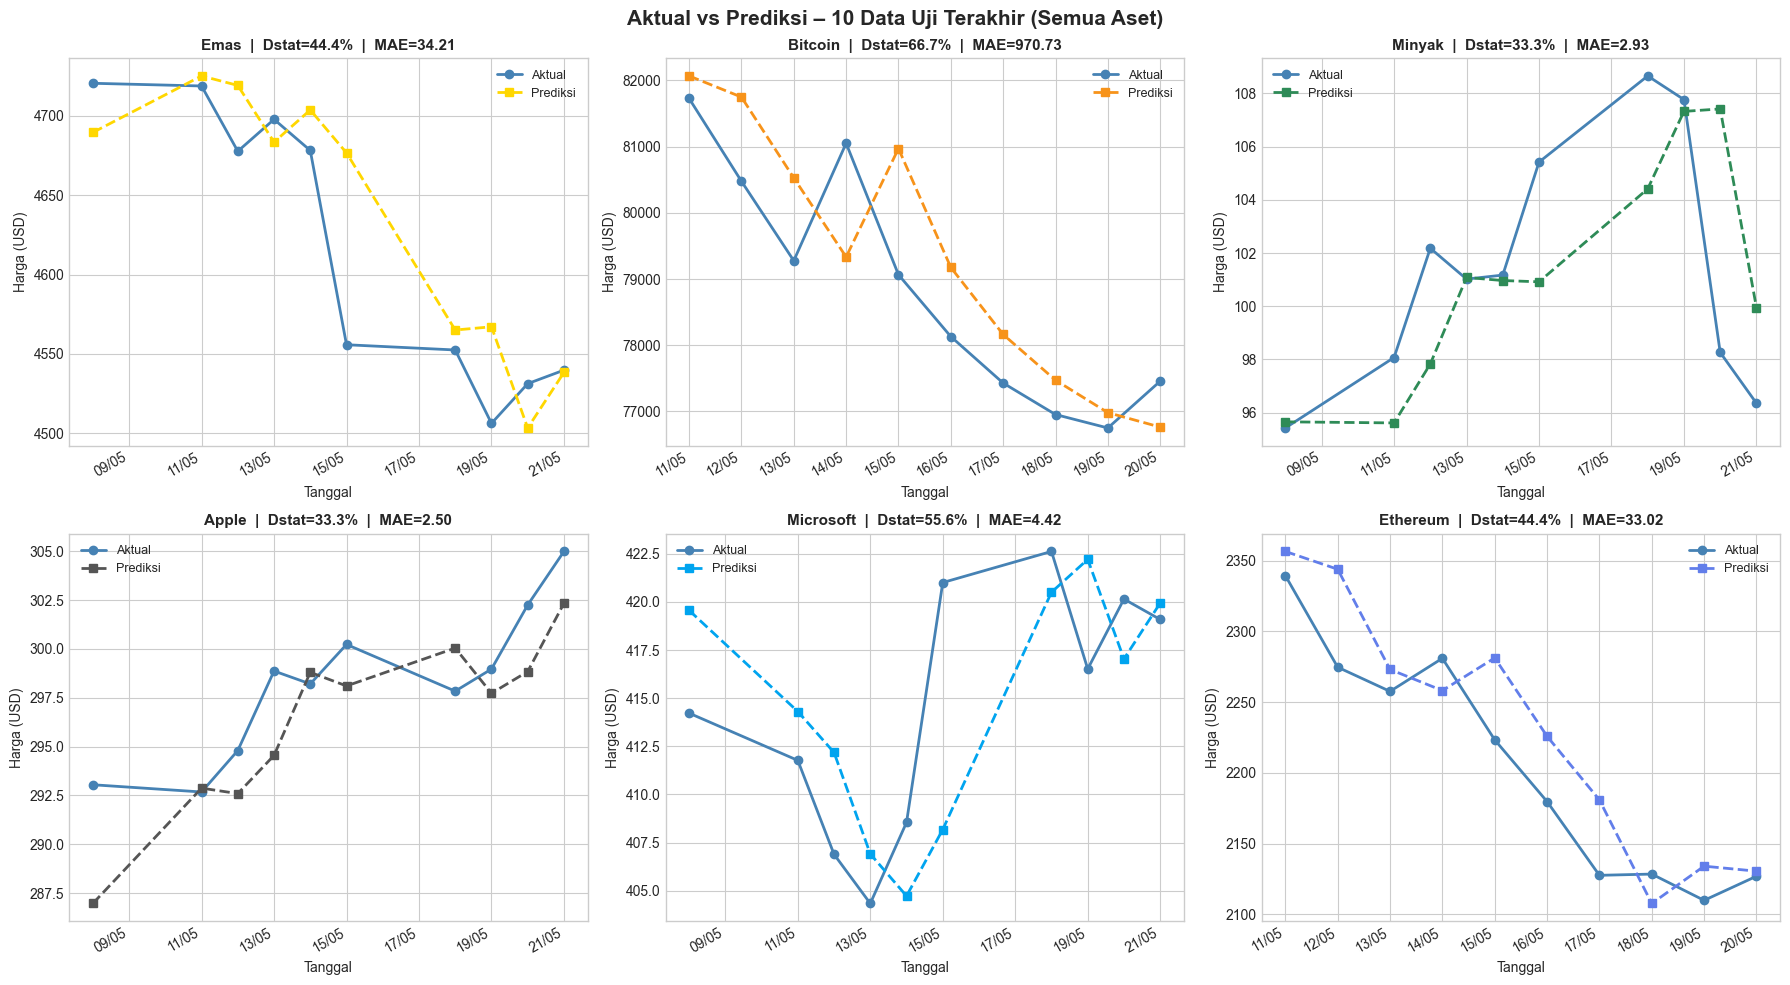

In [19]:
display(Image(filename=str(OUTPUT_DIR / 'eval_actual_vs_predicted.png'), width=950))


### 9.2 Perbandingan Metrik Antar Aset

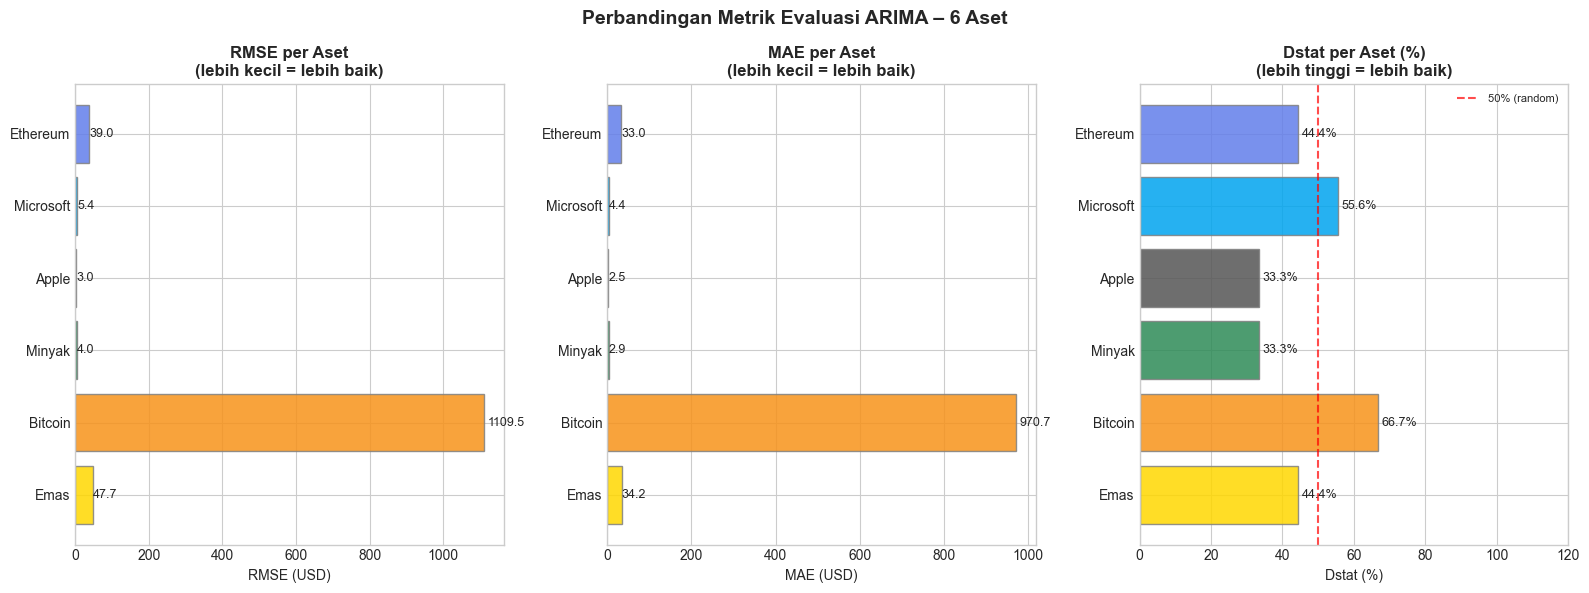

In [20]:
display(Image(filename=str(OUTPUT_DIR / 'eval_metrics_comparison.png'), width=850))


**Interpretasi:**
- RMSE/MAE tidak bisa dibandingkan langsung karena perbedaan skala harga
- **Dstat** adalah metrik perbandingan yang adil (hanya ukur arah, bukan besaran)
- **Bitcoin** memiliki Dstat tertinggi (66.7%) — terbaik dalam memprediksi arah
- **Microsoft** di posisi kedua (55.6%)


## 10. Prediksi 30 Hari ke Depan & Evaluasi Visual

Model di-retrain menggunakan **seluruh data** (train + test) untuk menghasilkan prediksi
30 hari ke depan yang lebih akurat, dilengkapi **Confidence Interval 95%**.

Setiap chart individual menampilkan **2 panel**:
- **Panel 1 (atas)**: historis 60 hari + overlay **actual vs predicted** pada test period
  → menunjukkan seberapa akurat model pada data yang sudah diketahui
- **Panel 2 (bawah)**: test period + **forecast 30 hari ke depan** + CI 95%
  → menunjukkan proyeksi dengan D+1 dan D+30 teranotasi


In [21]:
df_fc = pd.read_csv(OUTPUT_DIR / 'forecast_30days_all.csv', parse_dates=['Tanggal'])

print(f'RINGKASAN PREDIKSI {FORECAST_DAYS} HARI KE DEPAN')
print('=' * 80)
print(f'  {"Aset":<12} {"Sekarang":>12} {"D+1":>10} {"D+15":>10} {"D+30":>10} {"Perubahan":>12}')
print('  ' + '-' * 70)

for name, close in close_series.items():
    fc_aset = df_fc[df_fc['Aset'] == name].sort_values('Tanggal')
    cur = float(close.iloc[-1])
    d1  = float(fc_aset['Prediksi'].iloc[0])
    d15 = float(fc_aset['Prediksi'].iloc[14]) if len(fc_aset) >= 15 else float(fc_aset['Prediksi'].iloc[-1])
    d30 = float(fc_aset['Prediksi'].iloc[-1])
    ci_l = float(fc_aset['CI_Bawah_95'].iloc[-1])
    ci_h = float(fc_aset['CI_Atas_95'].iloc[-1])
    chg  = (d30 - cur) / cur * 100
    print(f'  {name:<12} {cur:>12.2f} {d1:>10.2f} {d15:>10.2f} {d30:>10.2f} {chg:>+11.2f}%')
    print(f'  {"":<12} {"CI 95% D+30":>12}: [{ci_l:.2f}, {ci_h:.2f}]')


RINGKASAN PREDIKSI 30 HARI KE DEPAN
  Aset             Sekarang        D+1       D+15       D+30    Perubahan
  ----------------------------------------------------------------------
  Emas              4539.80    4534.61    4561.47    4588.46       +1.07%
                CI 95% D+30: [4230.54, 4946.37]
  Bitcoin          77457.77   77426.19   77426.47   77426.47       -0.04%
                CI 95% D+30: [61858.23, 92994.72]
  Minyak              96.35      97.57      98.54      98.44       +2.17%
                CI 95% D+30: [79.72, 117.17]
  Apple              304.99     305.09     306.05     308.11       +1.02%
                CI 95% D+30: [278.17, 338.05]
  Microsoft          419.09     419.08     419.12     419.12       +0.01%
                CI 95% D+30: [365.42, 472.82]
  Ethereum          2126.98    2126.39    2126.75    2126.49       -0.02%
                CI 95% D+30: [1121.28, 3131.69]


### 10.1 Overview Forecast Semua Aset

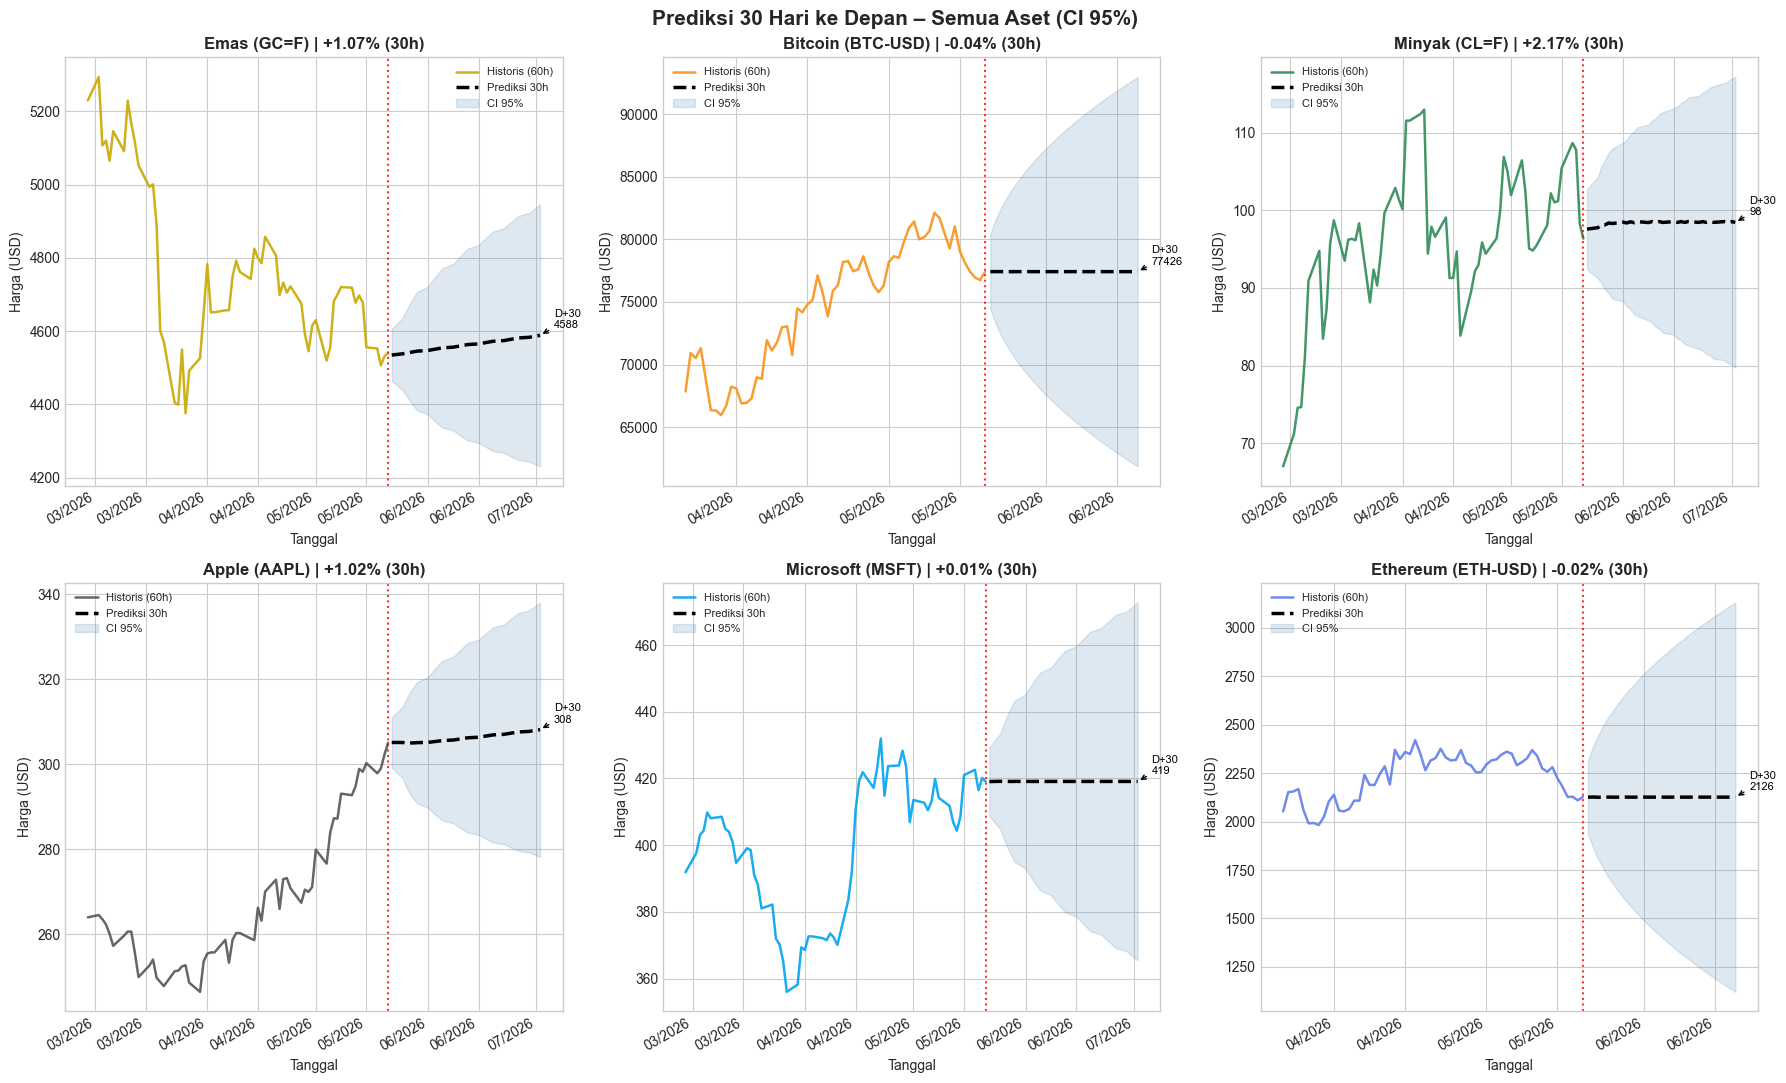

In [22]:
display(Image(filename=str(OUTPUT_DIR / 'forecast_chart_all.png'), width=950))


### 10.2 Combined Chart: Akurasi Model + Forecast Individual

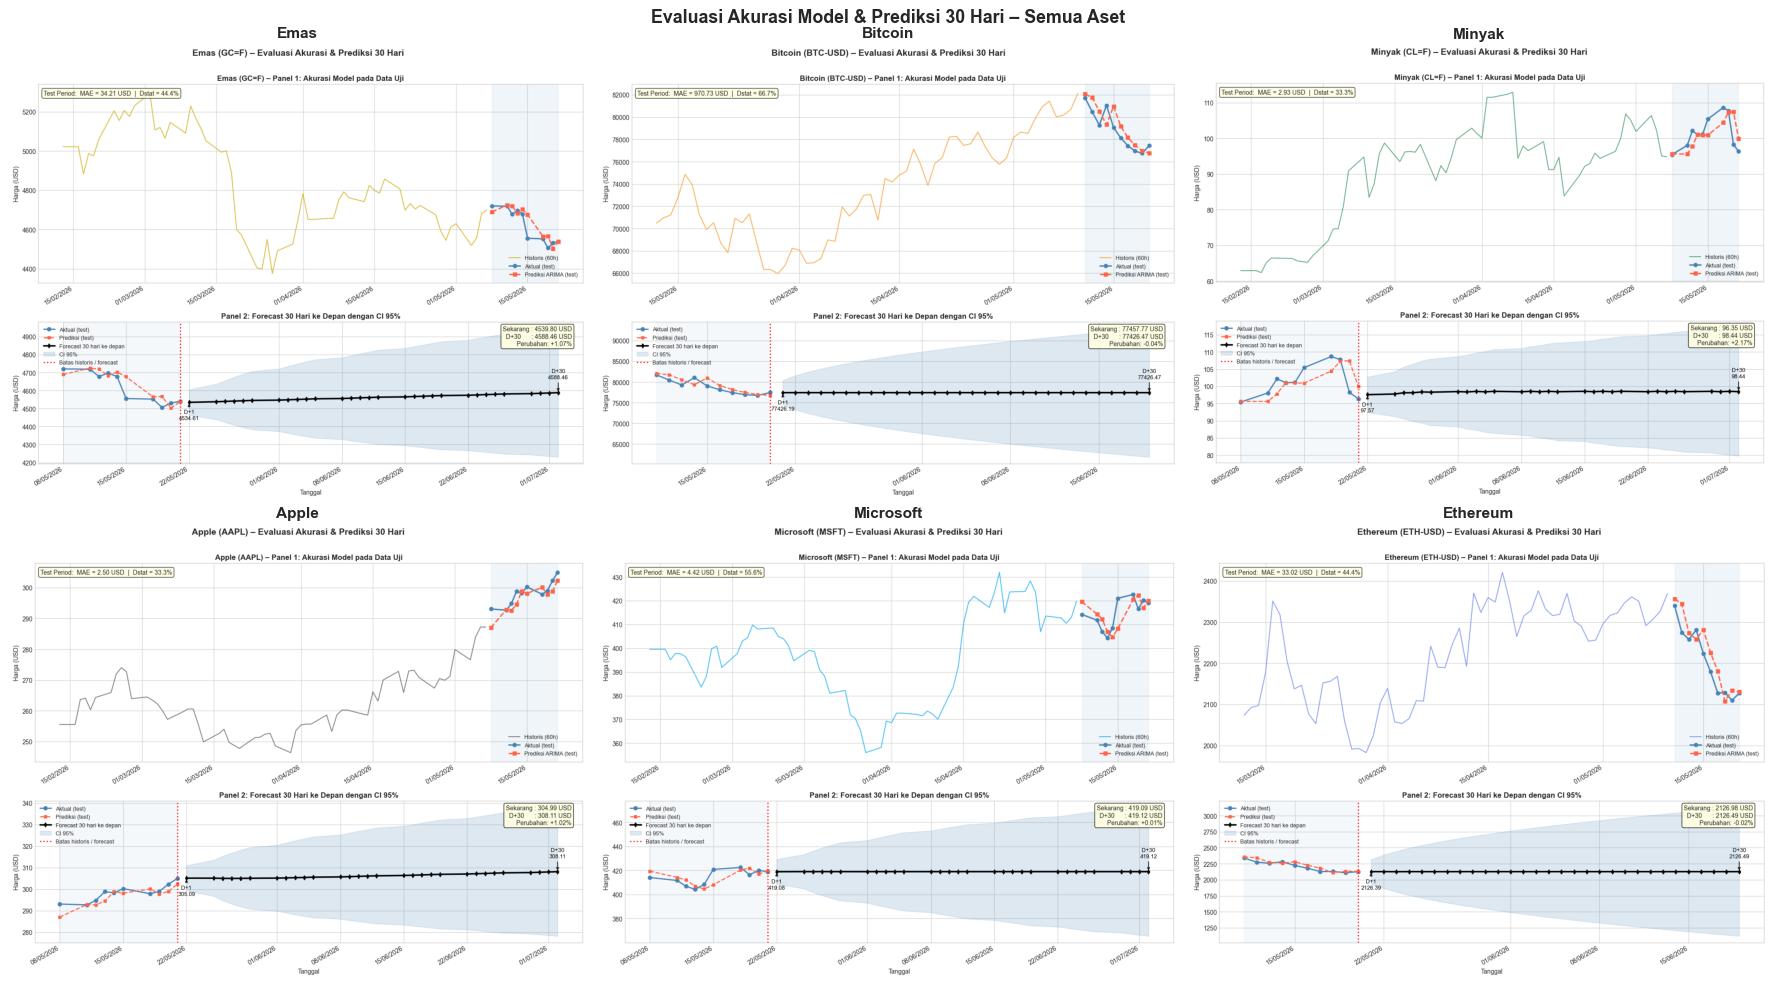

In [23]:
display(Image(filename=str(OUTPUT_DIR / 'combined_chart_all.png'), width=1050))


> **Cara membaca combined chart:**
> - **Panel atas**: Garis biru = harga aktual test period, garis merah putus = prediksi ARIMA.
>   Semakin berhimpitan = semakin akurat. Kotak kuning menampilkan MAE dan Dstat.
> - **Panel bawah**: Setelah garis merah putus-putus vertikal = wilayah masa depan.
>   Pita biru = Confidence Interval 95% — semakin lebar ke kanan berarti ketidakpastian makin besar.


### 10.3 Combined Chart Detail Per Aset

--- Emas ---


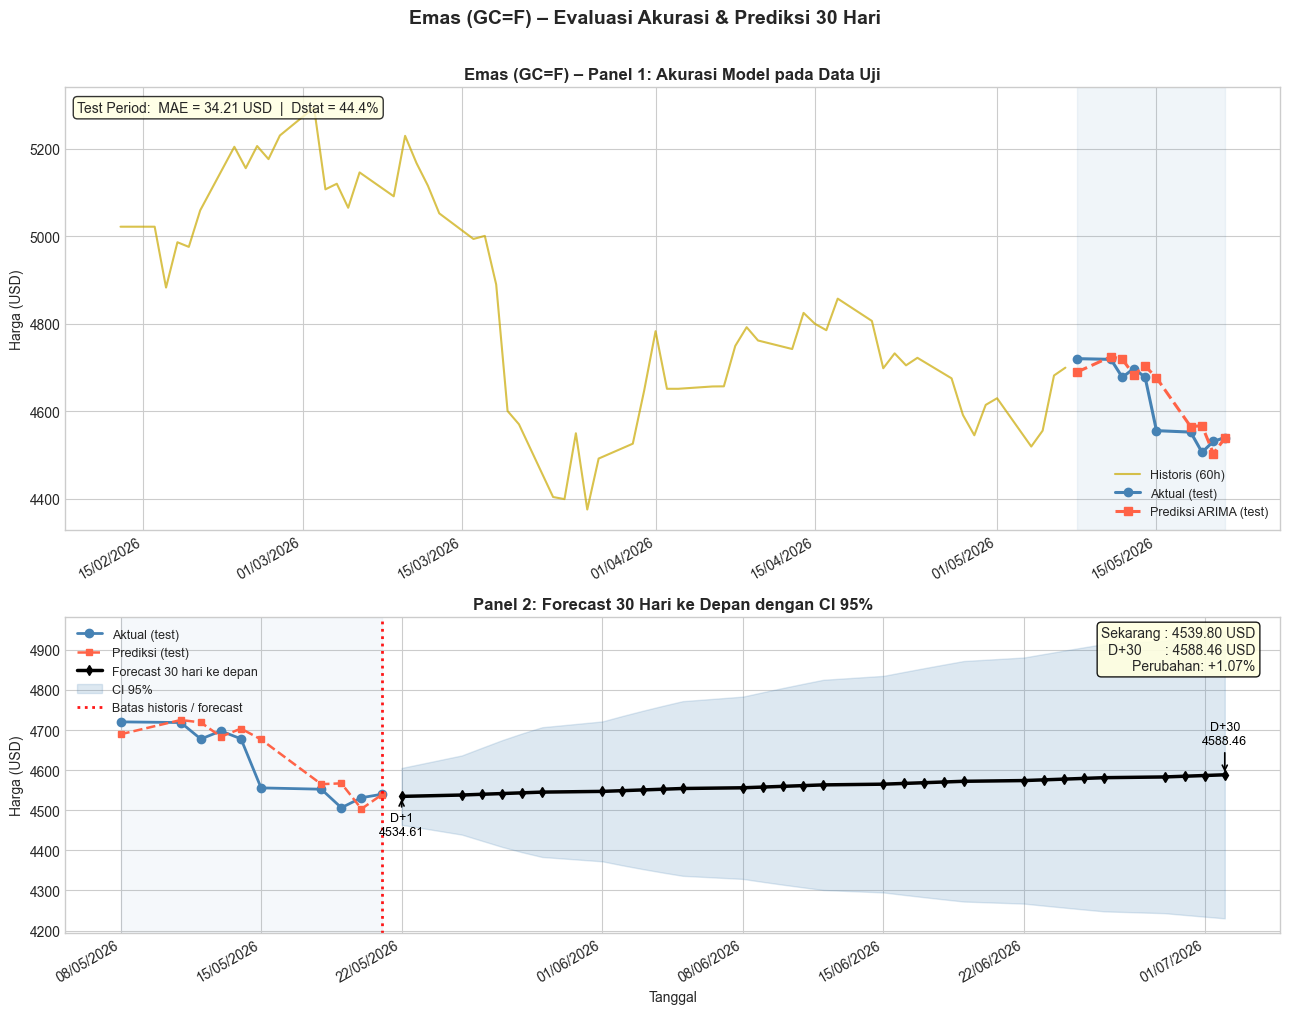

--- Bitcoin ---


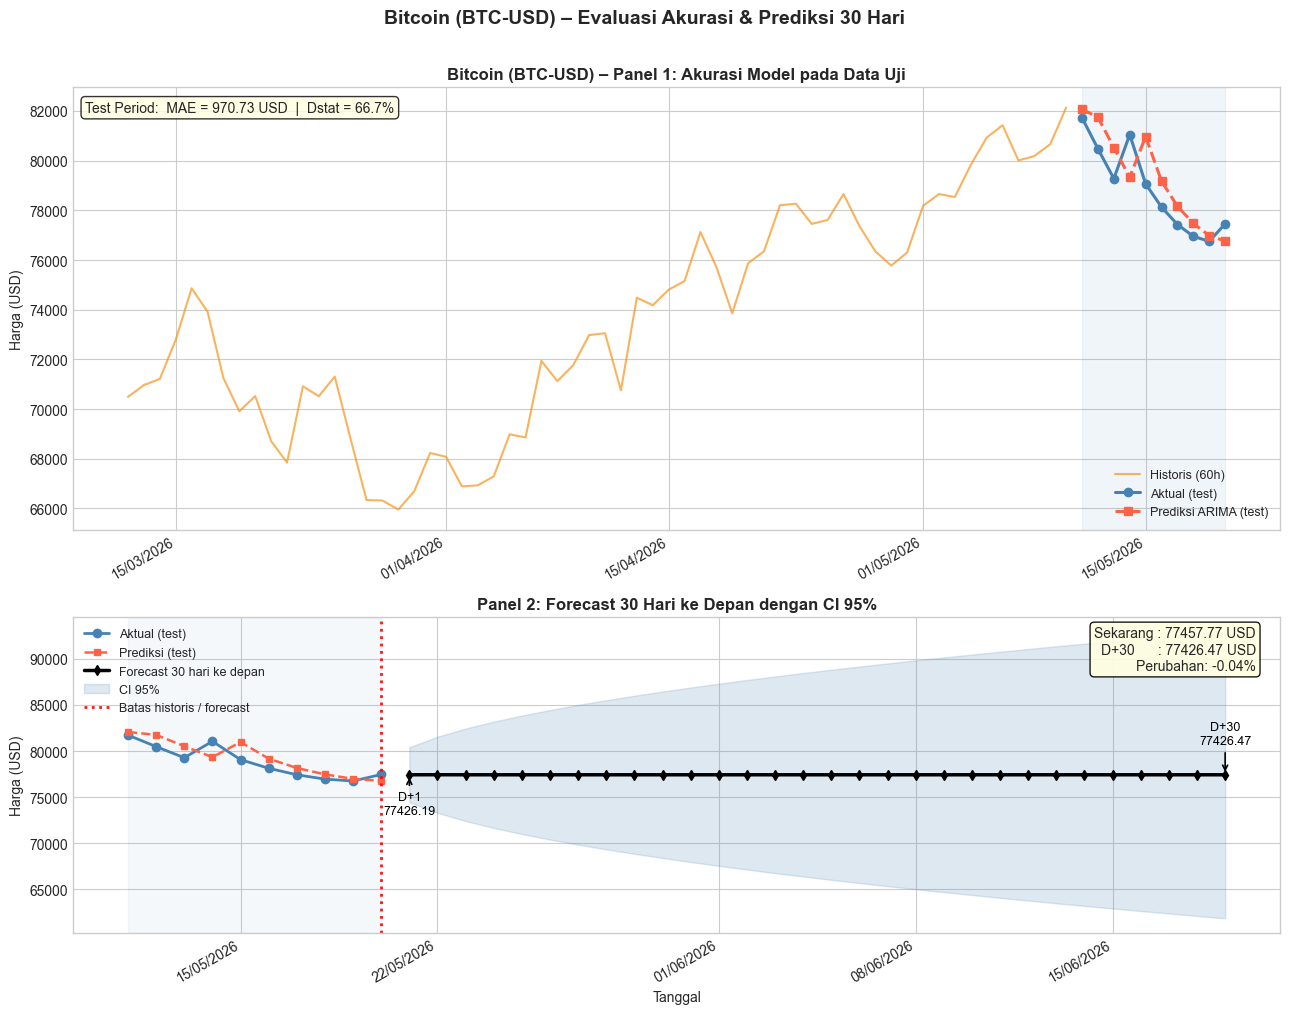

--- Minyak ---


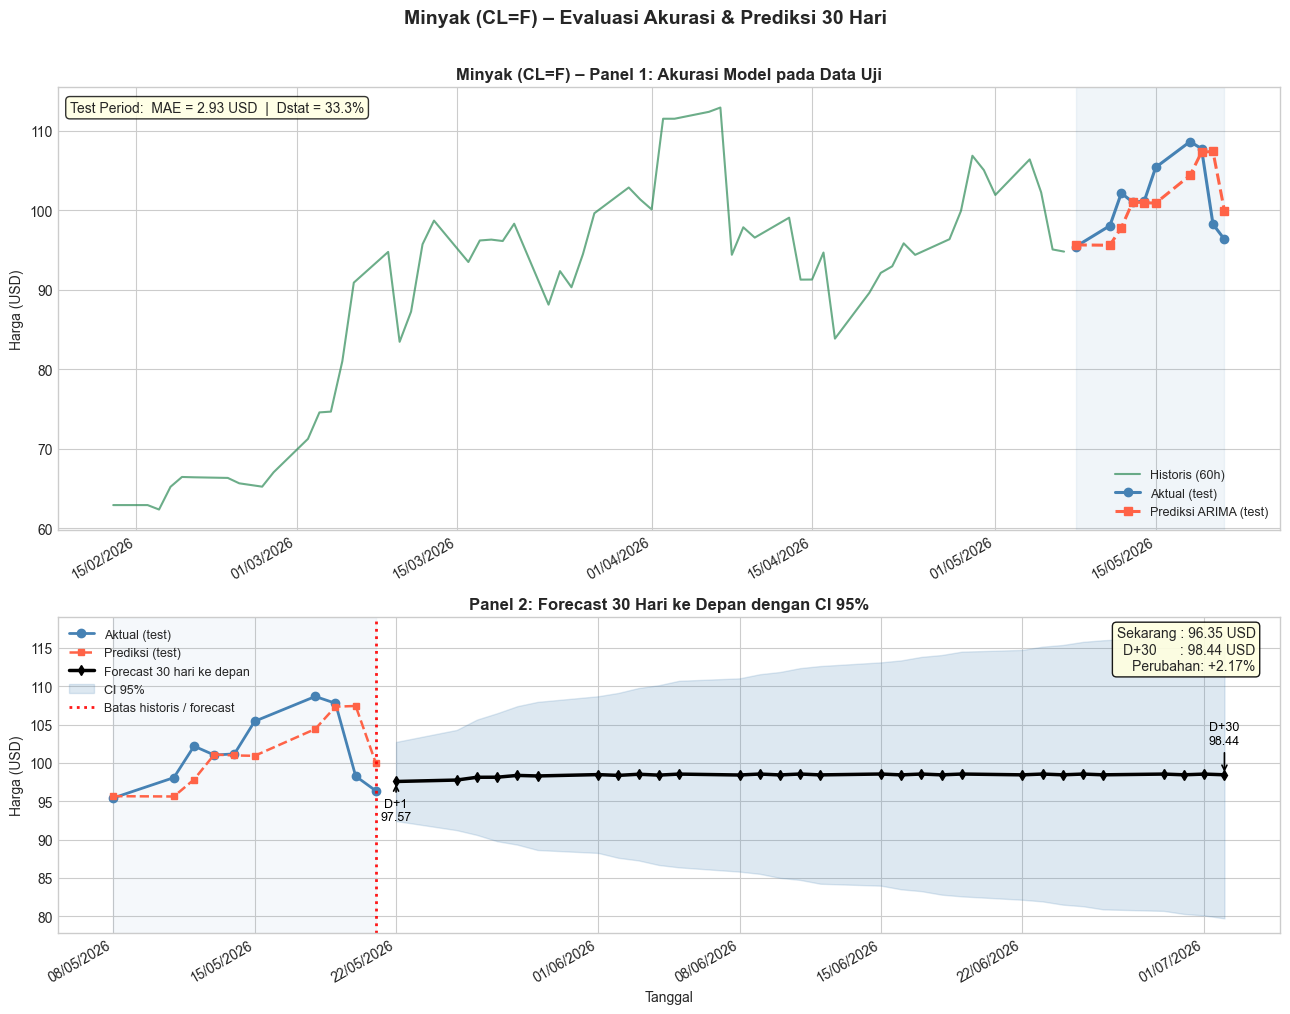

--- Apple ---


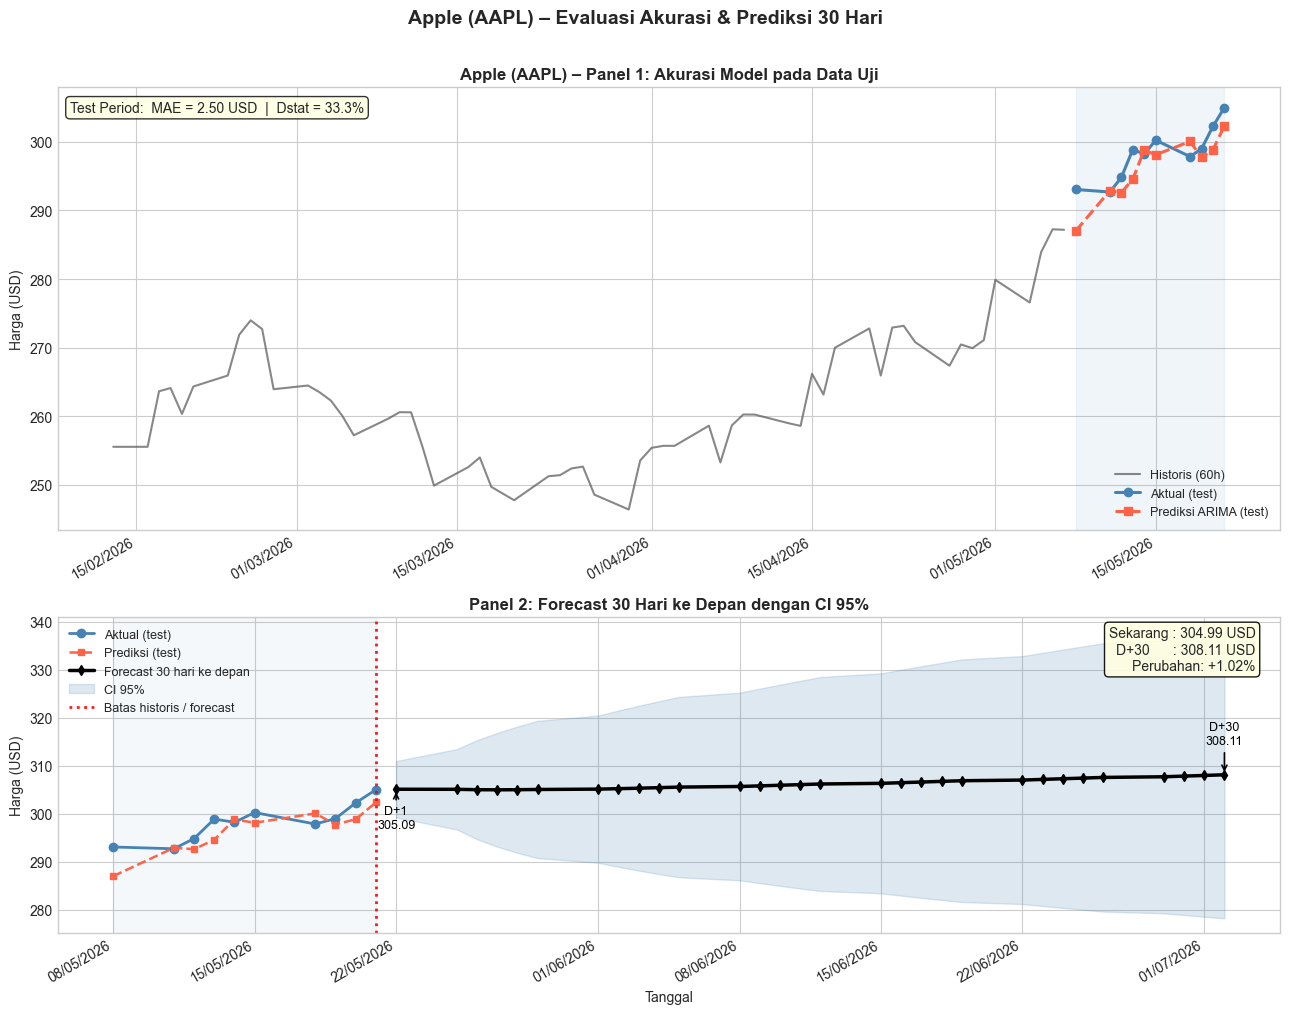

--- Microsoft ---


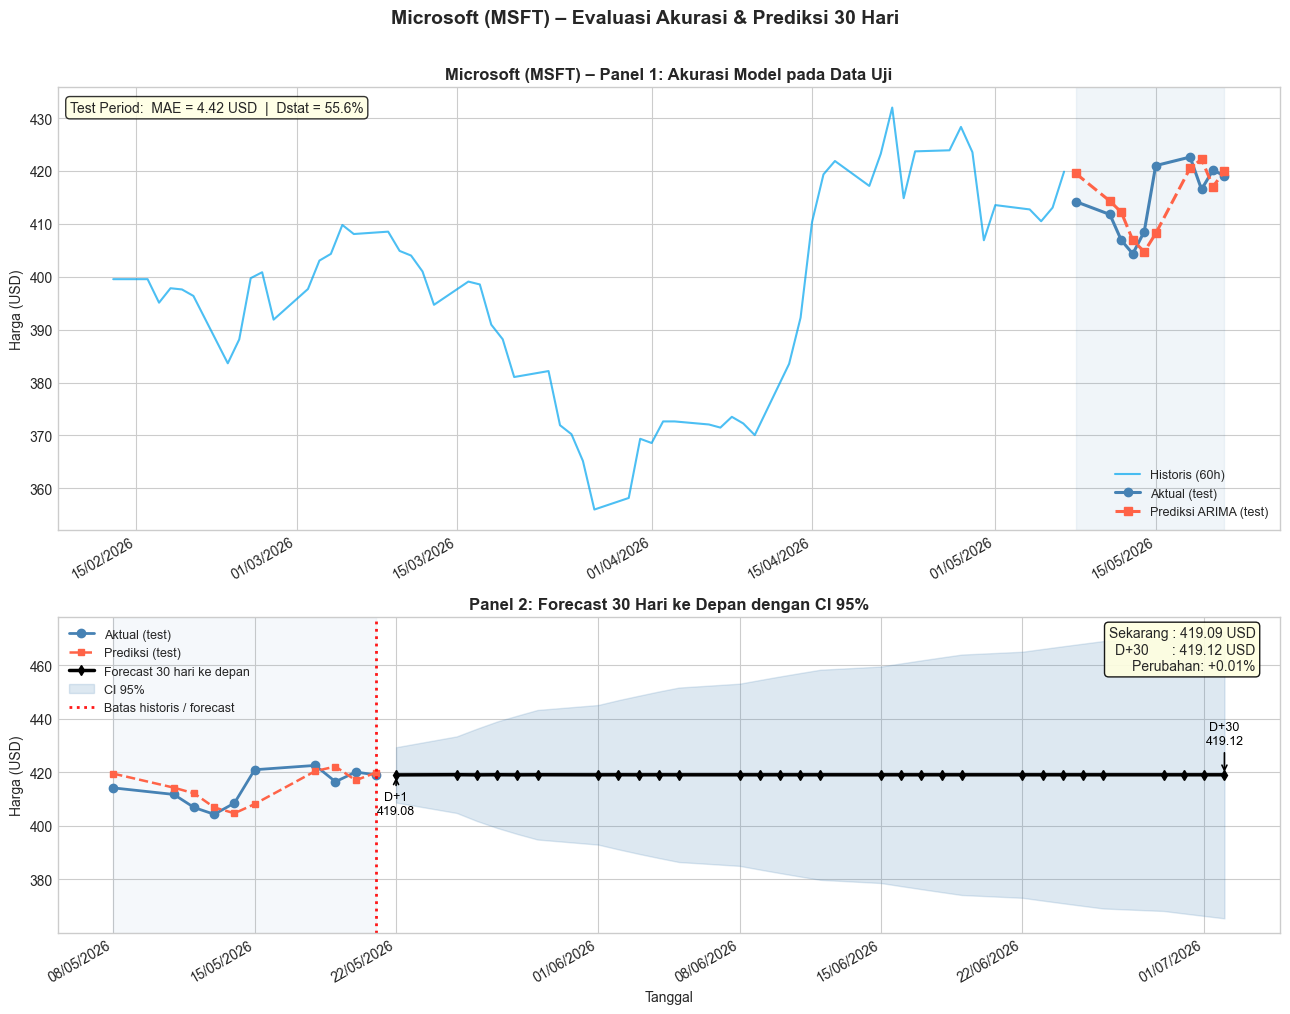

--- Ethereum ---


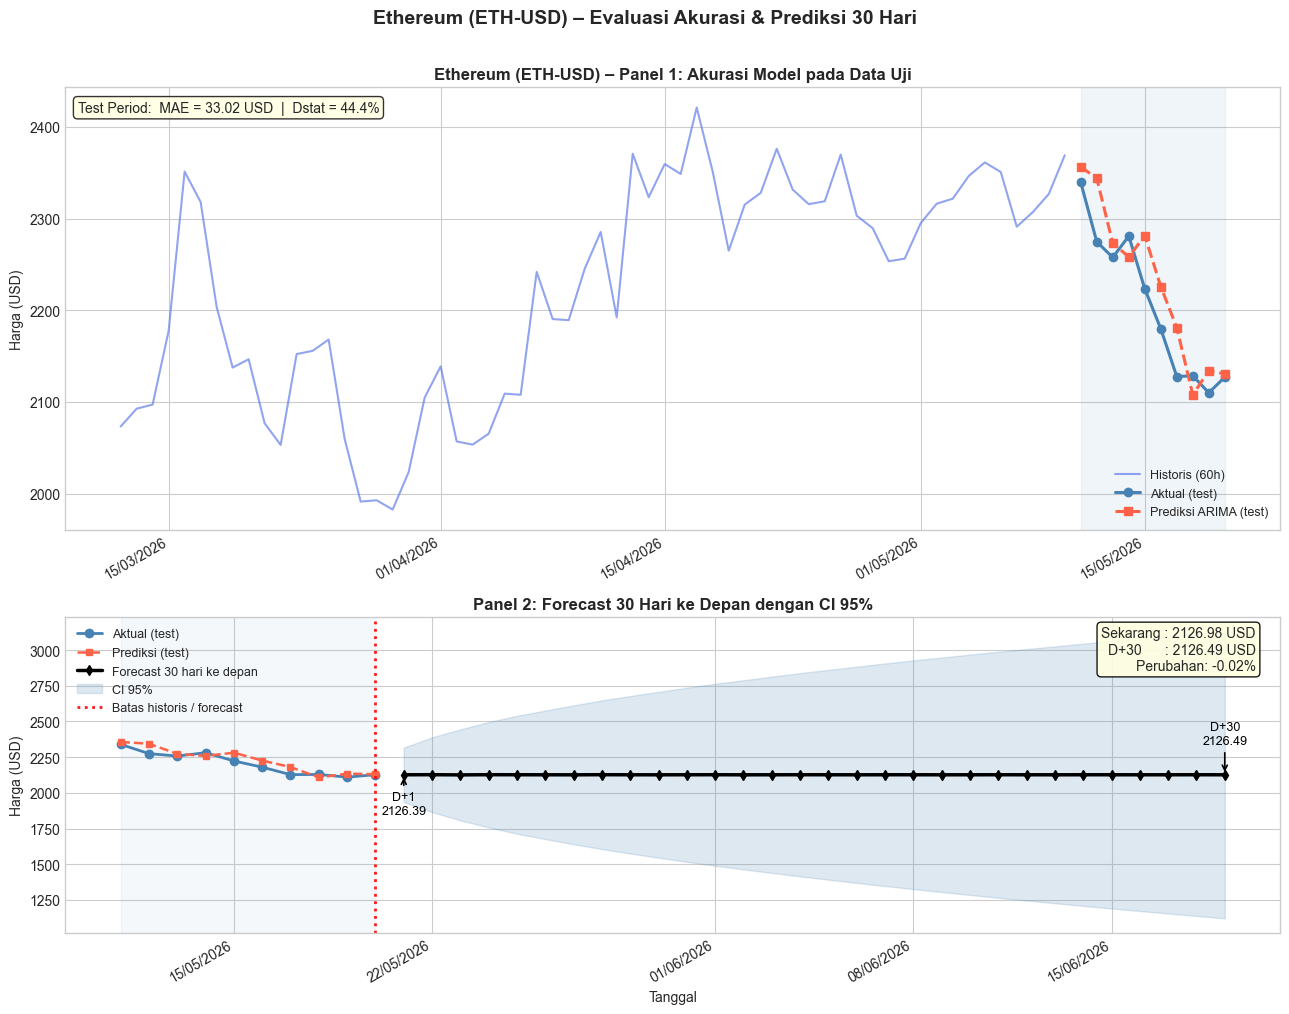

In [24]:
# Tampilkan setiap combined chart satu per satu
for name in ASSETS:
    chart_path = CHARTS_DIR / f'combined_{name}.png'
    print(f'--- {name} ---')
    display(Image(filename=str(chart_path), width=900))


## 11. Kesimpulan

### Ringkasan Temuan

**1. Stasioneritas**
Semua aset tidak stasioner pada level harga, stasioner setelah d=1 — validasi ARIMA(p,1,q).

**2. Parameter Optimal**

| Aset | Order | Trend | AIC |
|---|---|---|---|
| Emas | (0,1,3) | `'t'` | 16532.60 |
| Bitcoin | (0,1,3) | `'n'` | 40543.97 |
| Minyak | (2,1,3) | `'n'` | 7882.73 |
| Apple | (1,1,3) | `'t'` | 8327.57 |
| Microsoft | (1,1,3) | `'n'` | 10188.42 |
| Ethereum | (3,1,3) | `'n'` | 27775.94 |

**3. Kinerja Model (Dstat)**

| Aset | Dstat | Interpretasi |
|---|---|---|
| Bitcoin | 66.7% | Lebih baik dari acak |
| Microsoft | 55.6% | Sedikit di atas acak |
| Emas / Ethereum | 44.4% | Di bawah 50% |
| Minyak / Apple | 33.3% | Lemah |

**4. Prediksi 30 Hari**
- ARIMA menghasilkan prediksi yang cenderung **flat atau sedikit bertrend** untuk semua aset.
  Ini adalah karakteristik inherent ARIMA untuk time series keuangan jangka panjang.
- Confidence Interval 95% melebar seiring waktu — ketidakpastian naik secara natural.
- Aset dengan `trend='t'` (Emas, Apple) menunjukkan slight upward drift (+1%).
- Aset kripto (Bitcoin, Ethereum) hampir flat karena tanpa drift.

### Keterbatasan ARIMA

1. **Model linear** — tidak menangkap pola non-linear (terutama kripto)
2. **Flat forecast** — MA terms habis setelah q langkah, prediksi mendekati mean
3. **Tidak mempertimbangkan faktor eksternal** — berita, sentimen, makroekonomi
4. **Volatilitas tidak dimodelkan** — GARCH lebih cocok untuk aset volatil tinggi

### Rekomendasi Pengembangan

| Model | Kelebihan |
|---|---|
| **LSTM** | Non-linear, cocok untuk kripto |
| **Prophet** | Pola musiman kuat |
| **GARCH** | Pemodelan volatilitas |
| **ARIMA + GARCH** | Harga + volatilitas sekaligus |

---
*Analisis ini bersifat akademis dan bukan merupakan saran investasi.*
